<a href="https://colab.research.google.com/github/Bima34157/data-science-2026/blob/main/pertemuan_5_zaldi_bima_aditya_220401010271.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pertemuan ke-5

- Nama    : Zaldi Bima Aditya
- NIM     : 220401010271
- Kelas   : IF405

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

Shape dataset: (244, 7)

Tipe data:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


Text(0.5, 0.01, 'Sumber: Dataset "tips" dari Seaborn  |  Visualisasi: Matplotlib & Seaborn  |  Pertemuan 5 — Data Science')

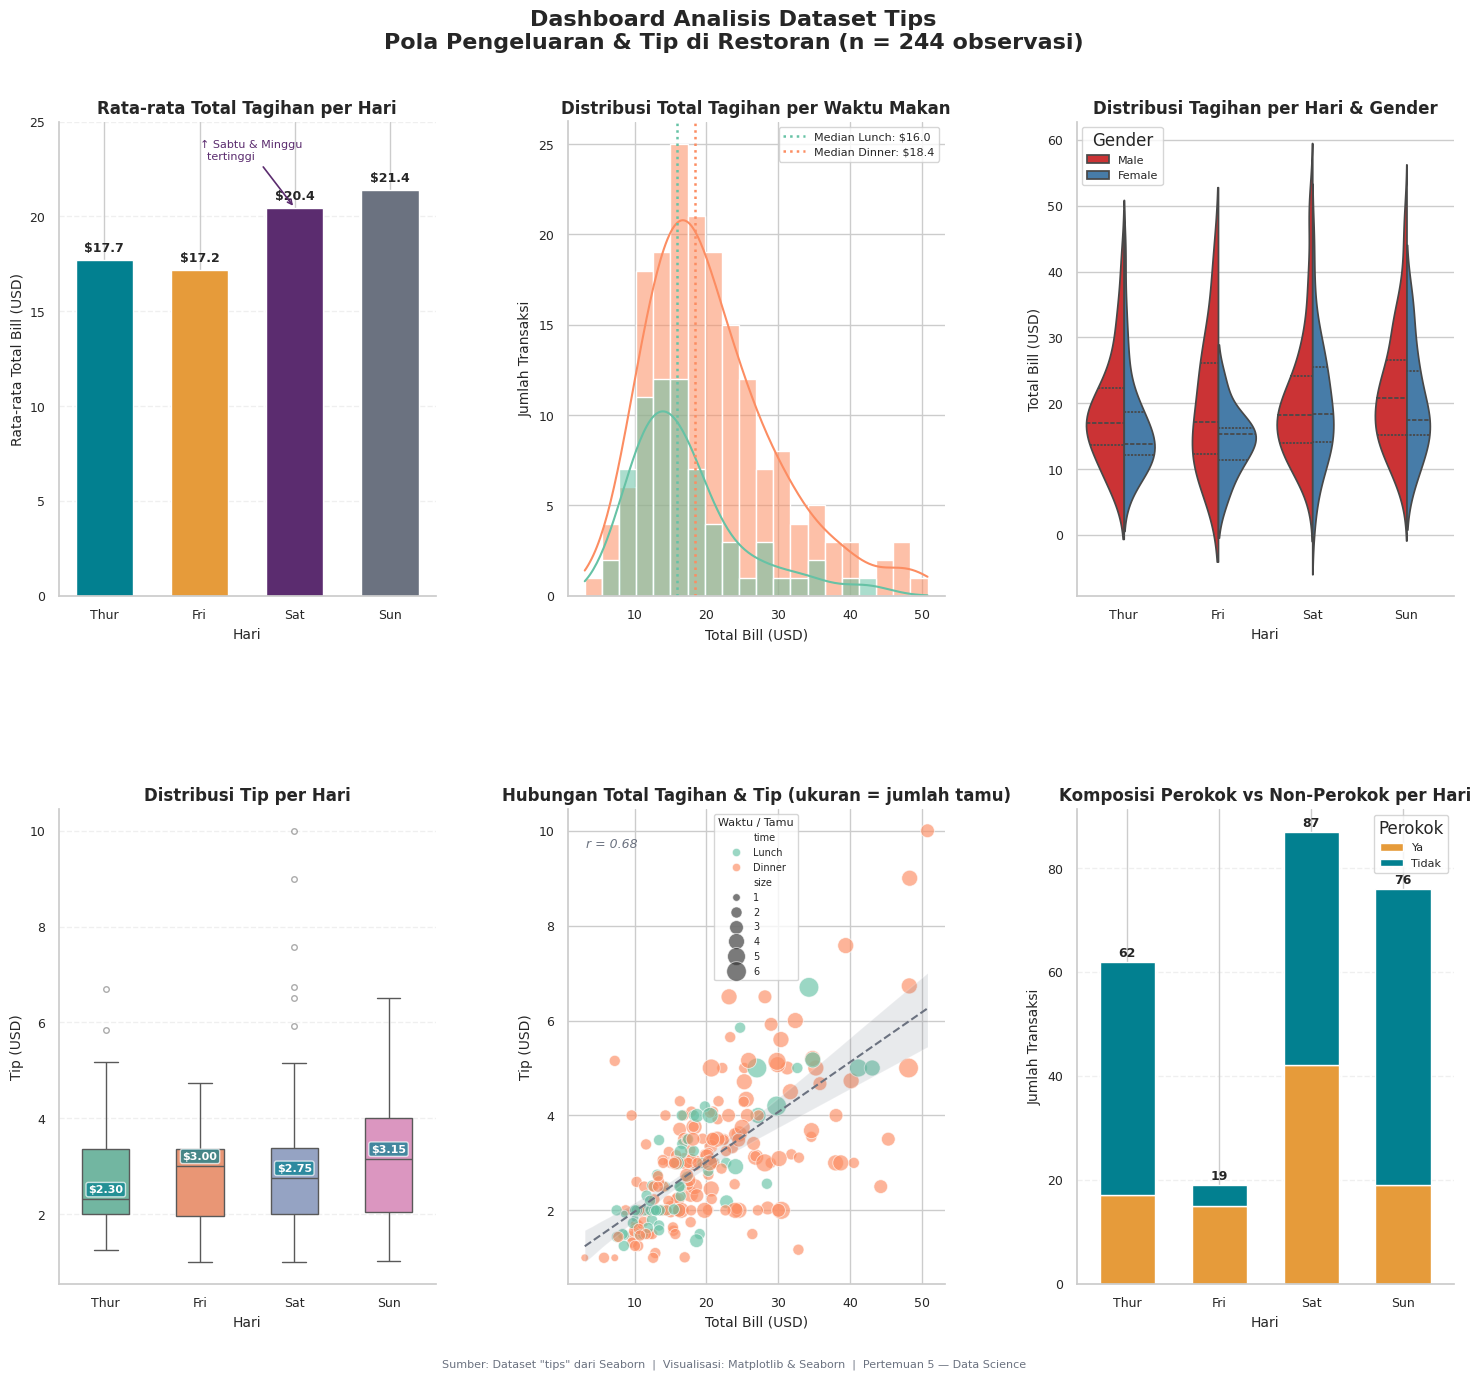

In [2]:
# ── 1. LOAD & INSPECT DATASET ─────────────────────────────────────────
df = sns.load_dataset('tips')
print("=" * 50)
print(f"Shape dataset: {df.shape}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nStatistik deskriptif:\n{df.describe().round(2)}")
print("=" * 50)

# ── 2. SETUP GLOBAL STYLE ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

COLORS = {
    'teal':   '#028090',
    'amber':  '#E69B3A',
    'purple': '#5B2C6F',
    'gray':   '#6B7280',
}

# ── 3. SETUP FIGURE LAYOUT ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    'Dashboard Analisis Dataset Tips\n'
    'Pola Pengeluaran & Tip di Restoran (n = 244 observasi)',
    fontsize=16, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.45, wspace=0.35,
    top=0.90, bottom=0.07
)

ax1 = fig.add_subplot(gs[0, 0])   # Bar chart
ax2 = fig.add_subplot(gs[0, 1])   # Histogram + KDE
ax3 = fig.add_subplot(gs[0, 2])   # Violin plot
ax4 = fig.add_subplot(gs[1, 0])   # Boxplot
ax5 = fig.add_subplot(gs[1, 1])   # Scatter plot
ax6 = fig.add_subplot(gs[1, 2])   # Stacked bar (komposisi)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 1 — Bar Chart: Rata-rata Tagihan per Hari
# ─────────────────────────────────────────────────────────────────────
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean().reindex(day_order)

bars = ax1.bar(
    avg_by_day.index, avg_by_day.values,
    color=[COLORS['teal'], COLORS['amber'], COLORS['purple'], COLORS['gray']],
    edgecolor='white', width=0.6
)
ax1.bar_label(bars, fmt='$%.1f', padding=4, fontsize=9, fontweight='bold')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Total Bill (USD)')
ax1.set_ylim(0, 25)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Anotasi insight
ax1.annotate(
    '↑ Sabtu & Minggu\n  tertinggi',
    xy=('Sat', avg_by_day['Sat']),
    xytext=('Fri', 23),
    fontsize=8, color=COLORS['purple'],
    arrowprops=dict(arrowstyle='->', color=COLORS['purple'], lw=1.2)
)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 2 — Histogram + KDE: Distribusi Total Tagihan per Waktu Makan
# ─────────────────────────────────────────────────────────────────────
sns.histplot(
    data=df, x='total_bill', hue='time',
    kde=True, palette='Set2', alpha=0.55,
    bins=20, ax=ax2
)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.set_xlabel('Total Bill (USD)')
ax2.set_ylabel('Jumlah Transaksi')
ax2.spines[['top', 'right']].set_visible(False)

# Garis median
for label, color in zip(['Lunch', 'Dinner'], ['#66C2A5', '#FC8D62']):
    med = df[df['time'] == label]['total_bill'].median()
    ax2.axvline(med, color=color, linestyle=':', linewidth=1.8,
                label=f'Median {label}: ${med:.1f}')
ax2.legend(fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 3 — Violin Plot: Distribusi Tagihan per Hari & Gender
# ─────────────────────────────────────────────────────────────────────
sns.violinplot(
    data=df, x='day', y='total_bill',
    hue='sex', palette='Set1',
    order=day_order, split=True,
    inner='quartile', ax=ax3
)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top', 'right']].set_visible(False)
ax3.legend(title='Gender', fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 4 — Boxplot: Perbandingan Tip per Hari
# ─────────────────────────────────────────────────────────────────────
sns.boxplot(
    data=df, x='day', y='tip',
    order=day_order,
    palette='Set2', width=0.5, hue='day', legend=False, ax=ax4,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
ax4.set_title('Distribusi Tip per Hari')
ax4.set_xlabel('Hari')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Tandai median
for i, day in enumerate(day_order):
    med = df[df['day'] == day]['tip'].median()
    ax4.text(i, med + 0.1, f'${med:.2f}',
             ha='center', va='bottom', fontsize=8, color='white',
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor=COLORS['teal'], alpha=0.7))

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 5 — Scatter Plot: Hubungan Tagihan & Tip
# ─────────────────────────────────────────────────────────────────────
sns.scatterplot(
    data=df, x='total_bill', y='tip',
    hue='time', size='size',
    sizes=(30, 200), palette='Set2',
    alpha=0.65, ax=ax5
)
sns.regplot(
    data=df, x='total_bill', y='tip',
    scatter=False, color=COLORS['gray'],
    line_kws={'linestyle': '--', 'linewidth': 1.5},
    ax=ax5
)

# Hitung korelasi
corr = df[['total_bill', 'tip']].corr().iloc[0, 1]
ax5.text(0.05, 0.92, f'r = {corr:.2f}',
         transform=ax5.transAxes, fontsize=9,
         color=COLORS['gray'], style='italic')

ax5.set_title('Hubungan Total Tagihan & Tip (ukuran = jumlah tamu)')
ax5.set_xlabel('Total Bill (USD)')
ax5.set_ylabel('Tip (USD)')
ax5.spines[['top', 'right']].set_visible(False)
ax5.legend(title='Waktu / Tamu', fontsize=7, title_fontsize=8)

# ─────────────────────────────────────────────────────────────────────
# GRAFIK 6 — Stacked Bar: Komposisi Perokok vs Non-Perokok per Hari
# ─────────────────────────────────────────────────────────────────────
smoker_counts = df.groupby(['day', 'smoker'], observed=False).size().unstack(fill_value=0)
smoker_counts = smoker_counts.reindex(day_order)

smoker_counts.plot(
    kind='bar', stacked=True, ax=ax6,
    color=[COLORS['amber'], COLORS['teal']],
    edgecolor='white', width=0.6
)
ax6.set_title('Komposisi Perokok vs Non-Perokok per Hari')
ax6.set_xlabel('Hari')
ax6.set_ylabel('Jumlah Transaksi')
ax6.tick_params(axis='x', rotation=0)
ax6.spines[['top', 'right']].set_visible(False)
ax6.legend(title='Perokok', labels=['Ya', 'Tidak'], fontsize=8)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

# Label total di atas tiap bar
totals = smoker_counts.sum(axis=1)
for i, total in enumerate(totals):
    ax6.text(i, total + 0.5, str(int(total)),
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 4. FOOTER ─────────────────────────────────────────────────────────
fig.text(
    0.5, 0.01,
    'Sumber: Dataset "tips" dari Seaborn  |  Visualisasi: Matplotlib & Seaborn  |  Pertemuan 5 — Data Science',
    ha='center', fontsize=8, color=COLORS['gray']
)

In [3]:
import os

# ── 5. EKSPOR ─────────────────────────────────────────────────────────
output_path = '/content/dashboard_tips.png'

# Create the directory if it doesn't exist
output_dir = os.path.dirname(output_path)
# Only create directory if output_path includes a directory (i.e., not just a filename)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()
print(f"\n✅ Dashboard berhasil disimpan: {output_path}")


✅ Dashboard berhasil disimpan: /content/dashboard_tips.png


# Penjelasan Dashboard Analisis Dataset Tips

# Grafik 1 — Bar Chart: Rata-rata Total Tagihan per Hari

**What? (Apa yang terlihat?)**

Grafik batang menampilkan rata-rata total tagihan (total_bill) pelanggan pada setiap hari operasional restoran, yaitu Kamis (Thur), Jumat (Fri), Sabtu (Sat), dan Minggu (Sun). Terlihat bahwa rata-rata tagihan tertinggi terjadi pada hari Minggu dan Sabtu, sedangkan hari Jumat memiliki rata-rata tagihan paling rendah.

**So What? (Mengapa ini penting?)**

Perbedaan rata-rata tagihan menunjukkan bahwa perilaku konsumsi pelanggan berubah tergantung hari kunjungan. Akhir pekan cenderung menghasilkan transaksi yang lebih besar karena pelanggan datang bersama keluarga atau kelompok yang lebih banyak sehingga total pengeluaran meningkat.

**Now What? (Apa tindak lanjutnya?)**

Manajemen restoran dapat meningkatkan persediaan bahan baku dan jumlah staf pada akhir pekan karena potensi pendapatan lebih tinggi. Selain itu, promosi khusus pada hari kerja dapat dilakukan untuk meningkatkan nilai transaksi rata-rata.

# Grafik 2 — Histogram + KDE: Distribusi Total Tagihan Berdasarkan Waktu Makan

**What? (Apa yang terlihat?)**

Histogram dan kurva KDE menunjukkan distribusi total tagihan yang dipisahkan berdasarkan waktu makan, yaitu Lunch dan Dinner. Distribusi Dinner lebih menyebar dan memiliki lebih banyak transaksi dengan nilai tagihan tinggi dibandingkan Lunch.

**So What? (Mengapa ini penting?)**

Perbedaan pola distribusi mengindikasikan bahwa pelanggan saat makan malam cenderung mengeluarkan uang lebih banyak dibandingkan pelanggan saat makan siang. Selain itu, terdapat variasi pengeluaran yang lebih besar pada sesi Dinner.

**Now What? (Apa tindak lanjutnya?)**

Restoran dapat mengembangkan strategi pemasaran yang berbeda untuk Lunch dan Dinner. Program promosi atau paket hemat dapat difokuskan pada Lunch untuk meningkatkan transaksi, sedangkan pada Dinner dapat ditawarkan menu premium atau paket keluarga untuk memaksimalkan pendapatan.

# Grafik 3 — Violin Plot: Distribusi Tagihan per Hari dan Gender

**What? (Apa yang terlihat?)**

Violin plot memperlihatkan distribusi total tagihan berdasarkan hari dan gender pelanggan. Bentuk violin menunjukkan kepadatan data, sedangkan garis kuartil menggambarkan persebaran nilai tagihan pada masing-masing kelompok.

**So What? (Mengapa ini penting?)**

Grafik menunjukkan bahwa terdapat perbedaan pola pengeluaran antara pelanggan laki-laki dan perempuan pada beberapa hari tertentu. Selain itu, akhir pekan menunjukkan distribusi yang lebih lebar yang menandakan variasi pengeluaran yang lebih besar dibandingkan hari kerja.

**Now What? (Apa tindak lanjutnya?)**

Analisis lanjutan dapat dilakukan untuk mengetahui apakah perbedaan tersebut dipengaruhi oleh ukuran kelompok pelanggan, jenis makanan yang dipesan, atau faktor lainnya. Hasil ini juga dapat membantu restoran menyusun strategi pemasaran yang lebih tersegmentasi.

# Grafik 4 — Boxplot: Distribusi Tip per Hari

**What? (Apa yang terlihat?)**

Boxplot menampilkan distribusi nilai tip yang diberikan pelanggan pada setiap hari. Terlihat median tip berbeda-beda antar hari serta terdapat beberapa outlier yang menunjukkan tip dengan nilai jauh lebih tinggi dibandingkan mayoritas transaksi.

**So What? (Mengapa ini penting?)**

Nilai tip dapat menjadi indikator kepuasan pelanggan maupun besarnya transaksi. Hari dengan median tip yang lebih tinggi menunjukkan potensi pendapatan tambahan yang lebih baik bagi pelayan restoran.

**Now What? (Apa tindak lanjutnya?)**

Perlu dilakukan analisis lebih lanjut untuk mengetahui faktor yang memengaruhi besarnya tip, misalnya kualitas layanan, ukuran kelompok pelanggan, atau total tagihan. Informasi ini dapat digunakan untuk meningkatkan kualitas pelayanan dan kepuasan pelanggan.

# Grafik 5 — Scatter Plot: Hubungan Total Tagihan dan Tip

**What? (Apa yang terlihat?)**

Scatter plot menunjukkan hubungan antara total tagihan (total_bill) dan tip yang diberikan pelanggan. Warna titik membedakan waktu makan, sedangkan ukuran titik menunjukkan jumlah tamu pada meja tersebut. Garis regresi menunjukkan tren hubungan antar variabel.

**So What? (Mengapa ini penting?)**

Terlihat adanya korelasi positif yang cukup kuat antara total tagihan dan tip. Semakin besar total tagihan pelanggan, semakin besar pula tip yang diberikan. Selain itu, meja dengan jumlah tamu lebih banyak cenderung menghasilkan tagihan dan tip yang lebih tinggi.

**Now What? (Apa tindak lanjutnya?)**

Restoran dapat meningkatkan pendapatan melalui strategi upselling, seperti menawarkan menu tambahan atau paket khusus yang meningkatkan nilai tagihan. Analisis lanjutan mengenai persentase tip terhadap total tagihan juga dapat memberikan gambaran yang lebih akurat mengenai perilaku pelanggan.

# Grafik 6 — Stacked Bar Chart: Komposisi Perokok dan Non-Perokok per Hari

**What? (Apa yang terlihat?)**

Grafik batang bertumpuk menampilkan jumlah pelanggan perokok dan non-perokok pada setiap hari operasional restoran. Tinggi batang menunjukkan total transaksi, sedangkan warna menunjukkan kategori pelanggan.

**So What? (Mengapa ini penting?)**

Grafik memperlihatkan komposisi pelanggan yang berbeda pada setiap hari. Sebagian besar transaksi berasal dari pelanggan non-perokok, namun proporsi pelanggan perokok tetap cukup signifikan pada beberapa hari tertentu.

**Now What? (Apa tindak lanjutnya?)**

Informasi ini dapat digunakan untuk pengaturan area merokok dan non-merokok yang lebih optimal. Restoran juga dapat mengevaluasi apakah fasilitas yang tersedia sudah sesuai dengan karakteristik mayoritas pelanggan pada masing-masing hari operasional.